In this notebook, we shall find the partial derivatives of two functions and verify them against their analytic expressions

## Function 1 :

$$ f(x,y) = x^2y + \sin(xy) $$

We want to find :

$$ \dfrac{\partial f}{\partial x} $$
and 
$$ \dfrac{\partial f}{\partial y} $$

Exact Gradients :

$$ \dfrac{\partial f}{\partial x} = 2xy + y\cos(xy) $$
$$ \dfrac{\partial f}{\partial y} = x^2 + x\cos(xy) $$

In [98]:
import torch
import matplotlib.pyplot as plt

In [99]:
# domain
x = torch.linspace(-5.0,5.0,101,requires_grad=True)
y = torch.linspace(-5.0,5.0,101,requires_grad=True)

# function values
x_mesh, y_mesh = torch.meshgrid(x,y)
f1 = x_mesh**2*y_mesh + torch.sin(x_mesh*y_mesh)

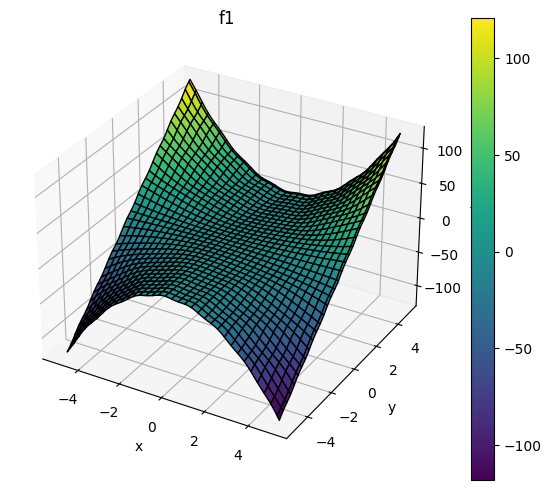

In [100]:
# visualising function
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    x_mesh.detach().numpy(),
    y_mesh.detach().numpy(),
    f1.detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)

fig.colorbar(surf, ax=ax)

ax.set_title("f1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f1")

plt.show()

In [101]:
# Evaluating gradients using AutoGrad
df1dx = torch.autograd.grad(
    outputs=f1,
    inputs=x_mesh,
    grad_outputs=torch.ones_like(x_mesh),
    create_graph=True
)[0]

df1dy = torch.autograd.grad(
    outputs=f1,
    inputs=y_mesh,
    grad_outputs=torch.ones_like(y_mesh),
    create_graph=True
)[0]

# Exact gradients
df1dx_exact = y_mesh*(2*x_mesh + torch.cos(x_mesh*y_mesh))
df1dy_exact = x_mesh*(x_mesh + torch.cos(x_mesh*y_mesh))

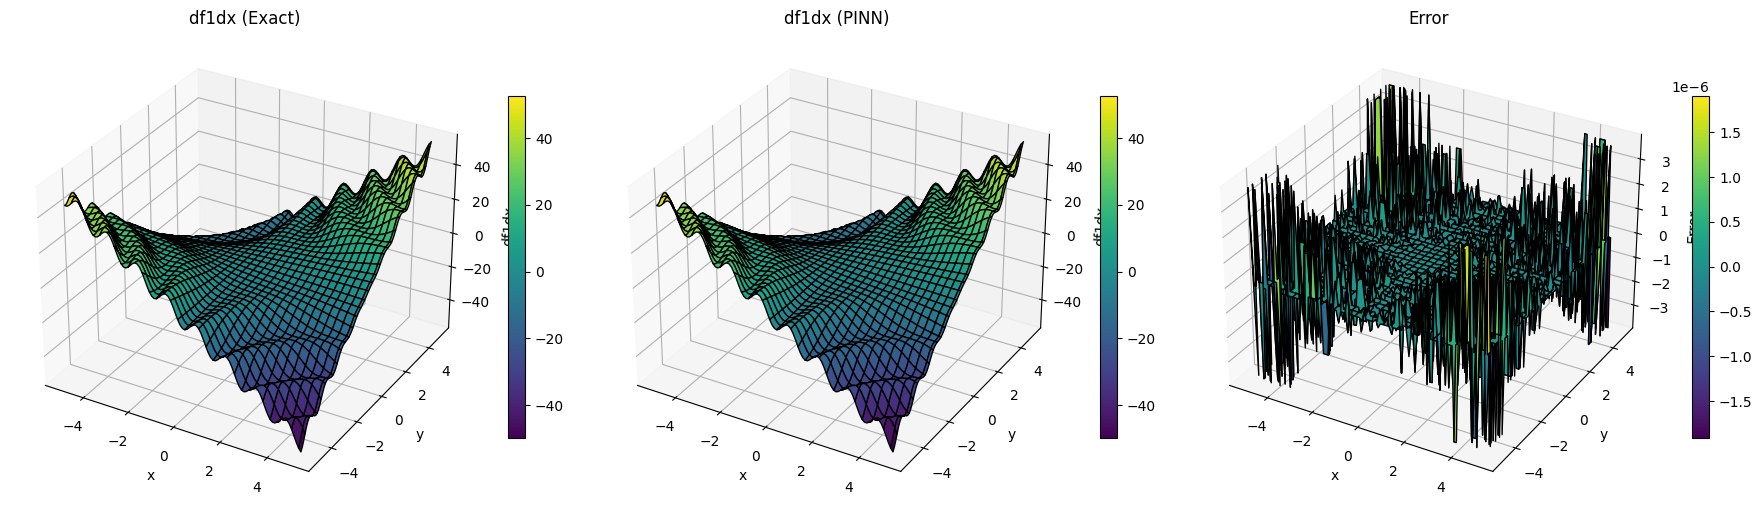

In [102]:
# Visualising the gradients w.r.t. 'x'

fig = plt.figure(figsize=(18, 6))

# Exact gradient
ax1 = fig.add_subplot(131, projection="3d")
surf1 = ax1.plot_surface(
    x_mesh.detach().numpy(),
    y_mesh.detach().numpy(),
    df1dx_exact.detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax1.set_title("df1dx (Exact)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("df1dx")
fig.colorbar(surf1, ax=ax1, shrink=0.6)

# PINN gradient
ax2 = fig.add_subplot(132, projection="3d")
surf2 = ax2.plot_surface(
    x_mesh.detach().numpy(),
    y_mesh.detach().numpy(),
    df1dx.detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax2.set_title("df1dx (PINN)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("df1dx")
fig.colorbar(surf2, ax=ax2, shrink=0.6)

# Error
ax3 = fig.add_subplot(133, projection="3d")
surf3 = ax3.plot_surface(
    x_mesh.detach().numpy(),
    y_mesh.detach().numpy(),
    (df1dx - df1dx_exact).detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax3.set_title("Error")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("Error")
fig.colorbar(surf3, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.show()

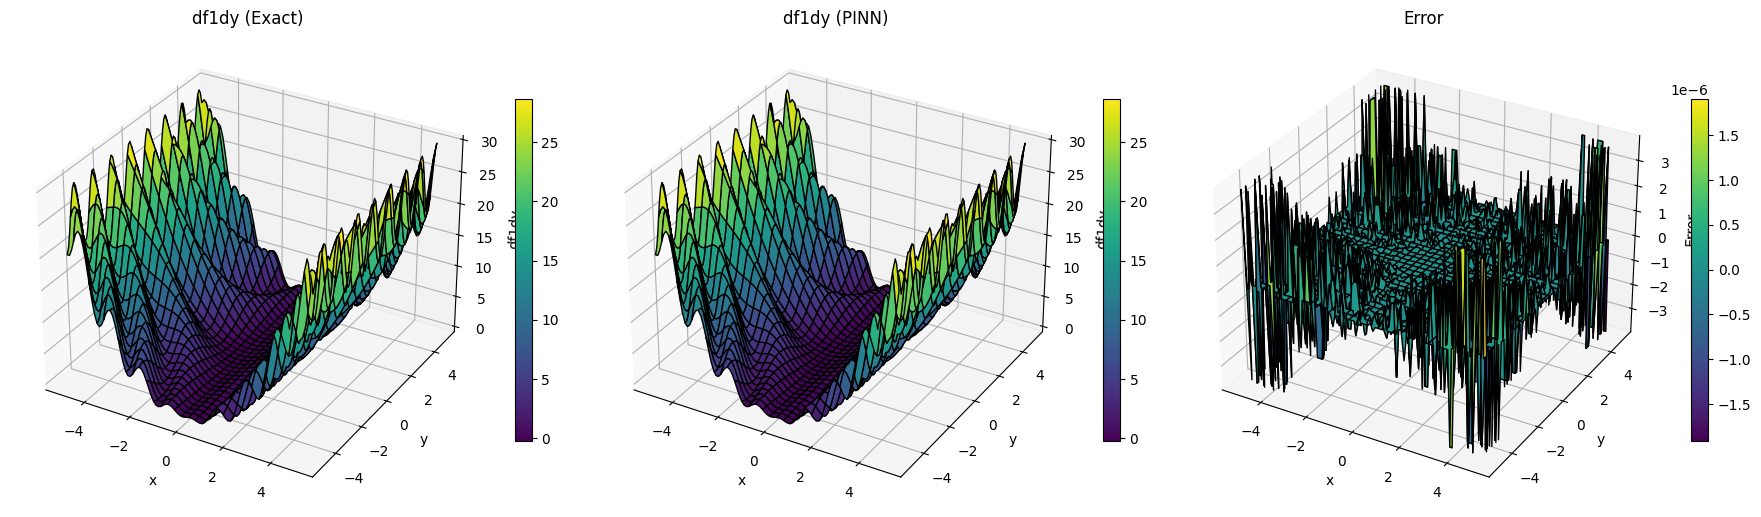

In [103]:
# Visualising the gradients w.r.t. 'y'

fig = plt.figure(figsize=(18, 6))

# Exact gradient
ax1 = fig.add_subplot(131, projection="3d")
surf1 = ax1.plot_surface(
    x_mesh.detach().numpy(),
    y_mesh.detach().numpy(),
    df1dy_exact.detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax1.set_title("df1dy (Exact)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("df1dy")
fig.colorbar(surf1, ax=ax1, shrink=0.6)

# PINN gradient
ax2 = fig.add_subplot(132, projection="3d")
surf2 = ax2.plot_surface(
    x_mesh.detach().numpy(),
    y_mesh.detach().numpy(),
    df1dy.detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax2.set_title("df1dy (PINN)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("df1dy")
fig.colorbar(surf2, ax=ax2, shrink=0.6)

# Error
ax3 = fig.add_subplot(133, projection="3d")
surf3 = ax3.plot_surface(
    x_mesh.detach().numpy(),
    y_mesh.detach().numpy(),
    (df1dx - df1dx_exact).detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax3.set_title("Error")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("Error")
fig.colorbar(surf3, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.show()

## Function 2 :

$$ f(x,t) = x^2t^3 $$

We want to find :

$$ f_x, f_t, f_{xt}, f_{tx} $$

Exact Gradients :

$$ f_x = 2xt $$
$$ f_t = x^2 $$
$$ f_{xt} = 2x $$
$$ f_{tx} = 2x $$

In [107]:
# domain
x = torch.linspace(-5.0,5.0,101,requires_grad=True)
t = torch.linspace(-5.0,5.0,101,requires_grad=True)

# function values
x_mesh, t_mesh = torch.meshgrid(x,y)
f2 = x_mesh**2*t_mesh**3

In [109]:
# Evaluating gradients using AutoGrad
df2dx = torch.autograd.grad(
    outputs=f2,
    inputs=x_mesh,
    create_graph=True,
    grad_outputs=torch.ones_like(x_mesh)
)[0]
df2dt = torch.autograd.grad(
    outputs=f2,
    inputs=t_mesh,
    create_graph=True,
    grad_outputs=torch.ones_like(t_mesh)
)[0]
d2f2dtdx = torch.autograd.grad(
    outputs=df2dt,
    inputs=x_mesh,
    create_graph=True,
    grad_outputs=torch.ones_like(x_mesh)
)[0]
d2f2dxdt = torch.autograd.grad(
    outputs=df2dt,
    inputs=x_mesh,
    create_graph=True,
    grad_outputs=torch.ones_like(x_mesh)
)[0]

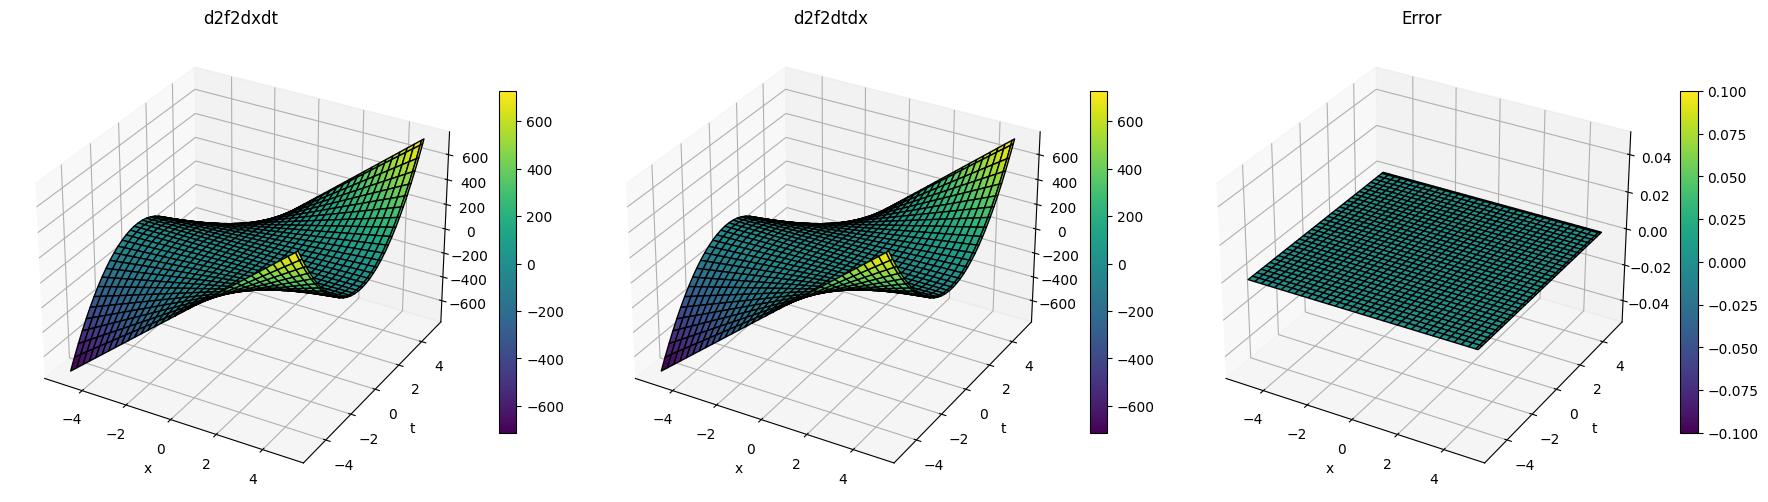

In [112]:
# Verifying that d2f2dxdt = d2f2dtdx

fig = plt.figure(figsize=(18, 6))

# Exact gradient
ax1 = fig.add_subplot(131, projection="3d")
surf1 = ax1.plot_surface(
    x_mesh.detach().numpy(),
    t_mesh.detach().numpy(),
    d2f2dxdt.detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax1.set_title("d2f2dxdt")
ax1.set_xlabel("x")
ax1.set_ylabel("t")
fig.colorbar(surf1, ax=ax1, shrink=0.6)

# PINN gradient
ax2 = fig.add_subplot(132, projection="3d")
surf2 = ax2.plot_surface(
    x_mesh.detach().numpy(),
    t_mesh.detach().numpy(),
    d2f2dtdx.detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax2.set_title("d2f2dtdx")
ax2.set_xlabel("x")
ax2.set_ylabel("t")
fig.colorbar(surf2, ax=ax2, shrink=0.6)

# Error
ax3 = fig.add_subplot(133, projection="3d")
surf3 = ax3.plot_surface(
    x_mesh.detach().numpy(),
    t_mesh.detach().numpy(),
    (d2f2dxdt - d2f2dtdx).detach().numpy(),
    cmap="viridis",
    edgecolor="black"
)
ax3.set_title("Error")
ax3.set_xlabel("x")
ax3.set_ylabel("t")
fig.colorbar(surf3, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.show()